# Modules

A *module* groups the components that make up a subsystem together with the
mechanisms and parameters that subsystem needs.  Where a
component describes an individual biomolecular part
and a mixture describes the context parts are compiled in, a module describes
a piece of the design: a sensing pathway, a genetic circuit, a reporter.

This notebook covers:

1. Defining a module and adding it to a mixture with `+`
2. Wiring modules together by shared names
3. Giving two modules different mechanisms for the same process
4. How mechanisms and parameters resolve between the levels
5. Using one module more than once with `instance`
6. Driving a whole model from a mixture parameter file

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import biocrnpyler as bcp
from biocrnpyler.utils.units import nM, uM, hrs

## Defining Modules and Adding Them to Mixtures

A module is created from a list of components, and may also be given the
mechanisms and parameters those components need.  Here the mechanisms the reporter
needs is left to the mixture, so the module is just a named group:

In [2]:
LacI = bcp.Protein('LacI')
plac = bcp.RepressiblePromoter('p_lac', LacI)
reporter = bcp.Module(
    name='IPTG_reporter',
    components=[
        bcp.DNAassembly('LacI', promoter='p_const', rbs='RBS1', protein=LacI),
        bcp.DNAassembly('GFP', promoter=plac, rbs='RBS2'),
        bcp.ChemicalComplex(['IPTG', LacI]),
    ],
)
reporter

Module: IPTG_reporter
Components = [
	DNAassembly: LacI
	DNAassembly: GFP
	ChemicalComplex: IPTG_protein_LacI ]

A module cannot be compiled on its own, since it describes a design
rather than a context.  It is added to a mixture with `+`, which returns a new
mixture and leaves the original alone:

In [3]:
cytosol = bcp.PURE(name='cytosol')
system = cytosol + reporter

crn = system.compile_crn()
print(crn.pretty_print(show_rates=False, show_keys=False))

Species(N = 21) = {
    metabolite[Fuel_CP] (@ 16666.0),  
    metabolite[AAs] (@ 6000.0),  
    metabolite[NTPs] (@ 4000.0),  
    metabolite[ATP] (@ 1000.0),  
    protein[Ribo] (@ 3.0),  
    protein[RNAP] (@ 1.3),  
    complex[protein[Ribo]:rna[LacI]] (@ 0),  
    complex[protein[Ribo]:rna[GFP]] (@ 0),  
    complex[metabolite[AAs]:4x_metabolite[ATP]:protein[Ribo]:rna[LacI]] (@ 0),  
    complex[metabolite[AAs]:4x_metabolite[ATP]:protein[Ribo]:rna[GFP]] (@ 0),  
    complex[dna[LacI]:protein[RNAP]] (@ 0),  
    complex[dna[LacI]:metabolite[NTPs]:protein[RNAP]] (@ 0),  
    protein[LacI] (@ 0),  
    rna[LacI] (@ 0),  
    dna[LacI] (@ 0),  
    complex[IPTG:protein[LacI]] (@ 0),  
    IPTG (@ 0),  
    protein[GFP] (@ 0),  
    rna[GFP] (@ 0),  
    dna[GFP] (@ 0),  
    metabolite[ADP] (@ 0),  
}

Reactions (16) = [
0. metabolite[Fuel_CP]+metabolite[ADP] --> metabolite[ATP]
1. metabolite[ATP] --> metabolite[ADP]
2. dna[LacI]+protein[RNAP] <--> complex[dna[LacI]:protein[RNAP]]
3. 

## Wiring Modules Together

Modules are connected by shared species.  Components in different modules that
share a type and a name compile to the same species, and are compiled only once, 
so a protein produced in one module and used by another is simply written with the
same name in both.

Below, `importer` expresses $\alpha$ hemolysin and imports IPTG.  This is connected
to the reporter we constructed earlier and internal IPTG is used to to drive
the reporter.  Note that we change the compartment for $\alpha$ hemolysin to 
`None` so that it matches the compartment for our `reporter`.

In [4]:
alphaHL = bcp.DNAassembly('alphaHL', promoter='pconst', rbs='RBS')
alphaHL_complex = bcp.IntegralMembraneProtein(
    alphaHL.protein, product='alphaHL', size=7, compartment=None)
alphaHL_channel = bcp.MembraneChannel(
    alphaHL_complex.product, substrate='IPTG', internal_compartment=None)

importer = bcp.Module(
    'importer',
    components=[alphaHL, alphaHL_complex, alphaHL_channel],
)

crn = (cytosol + importer + reporter).compile_crn()
species_list = [str(s) for s in crn.species]
IPTG_list = [item for item in species_list if "IPTG" in item]
print(IPTG_list)

['IPTG_external', 'IPTG', 'complex_IPTG_protein_LacI_']


## Two Modules, Two Different Models of the Same Process

A module's mechanisms apply to its own components, so two subsystems in the
same mixture can be modelled at different levels of detail.  Here one gene is
transcribed by a single lumped reaction while the other binds RNA polymerase
explicitly:

In [5]:
simple_gene = bcp.Module(
    'simple_module',
    components=[bcp.DNAassembly('A', promoter='pA', rbs='rA')],
    mechanisms={'transcription': bcp.SimpleTranscription()},
)

detailed_gene = bcp.Module(
    'detailed_module',
    components=[bcp.DNAassembly('B', promoter='pB', rbs='rB')],
    mechanisms={
        'transcription': bcp.Transcription_MM(bcp.Species('RNAP', 'protein'))
    },
)

simple_cytosol = bcp.PURE(
    include_resources=False, include_energy=False)

crn = (simple_cytosol + simple_gene + detailed_gene).compile_crn()
for reaction in crn.reactions:
    print(' ', reaction)

  dna[A] --> dna[A]+rna[A]
  rna[A]+protein[Ribo] <--> complex[protein[Ribo]:rna[A]]
  complex[protein[Ribo]:rna[A]] --> rna[A]+protein[A]+protein[Ribo]
  dna[B]+protein[RNAP] <--> complex[dna[B]:protein[RNAP]]
  complex[dna[B]:protein[RNAP]] --> dna[B]+rna[B]+protein[RNAP]
  rna[B]+protein[Ribo] <--> complex[protein[Ribo]:rna[B]]
  complex[protein[Ribo]:rna[B]] --> rna[B]+protein[B]+protein[Ribo]


Gene A is transcribed in one step, while gene B forms a complex with
RNA polymerase first.  Both appear in a single compiled CRN.

## How the Levels Resolve

Mechanisms and parameters are looked for from the inside out: a component's
own settings first, then its module's, then the mixture's.  An inner level
always wins, whatever keys are used:

In [6]:
def transcription_rate(crn, gene):
    """Rate constant of the reaction that produces rna_<gene>."""
    for reaction in crn.reactions:
        outputs = [str(w.species) for w in reaction.outputs]
        inputs = [str(w.species) for w in reaction.inputs]
        if f'rna_{gene}' in outputs and f'rna_{gene}' not in inputs:
            return reaction.propensity_type.k_forward

# The mixture's parameter file sets this rate under the mechanism's own
# name, which outranks a key given without a part_id, so the promoter is
# named here.  Reaction parameters are addressed by part_id, which for
# transcription is the promoter name (see section 6).
KTX = ('transcription', 'pA', 'ktx')

mixture = bcp.PURE(name='cytosol')
mixture.update_parameters(parameters={KTX: 1.0})

# nothing set on the module or the component: the mixture's value is used
plain = bcp.Module(
    'm', components=[bcp.DNAassembly('A', promoter='pA', rbs='rA')])

# the module overrides the mixture
with_module = bcp.Module(
    'm', components=[bcp.DNAassembly('A', promoter='pA', rbs='rA')],
    parameters={KTX: 2.0})

# and the component overrides its module, even though the key it uses
# here is the looser one: precedence goes by level, not by key
with_component = bcp.Module(
    'm',
    components=[bcp.DNAassembly(
        'A', promoter='pA', rbs='rA', parameters={'ktx': 3.0})],
    parameters={KTX: 2.0})

for label, module in [('mixture', plain), ('module', with_module),
                      ('component', with_component)]:
    rate = transcription_rate((mixture + module).compile_crn(), 'A')
    print(f'  ktx set at the {label:10s} level -> {rate}')

  ktx set at the mixture    level -> 0.001
  ktx set at the module     level -> 0.002
  ktx set at the component  level -> 0.003


The rates that come back are the values that were set divided by 1000.
This mixture transcribes with `Energy_Transcription_MM`, which produces RNA
at `ktx` / `length` while consuming nucleotides at `ktx`, so that a
transcript of the default length of 1000 costs 1000 NTPs.  It is the ratio
between the three levels that is being shown here, not the absolute rate.

Because an outer level never overrides an inner one, a value
written inside a module applies to every system that module is used in.  A
parameter that depends on the surrounding system is therefore better left
unspecified and set in the final mixture, as in section 6 below.

Mechanisms have one extra level that parameters do not: a *default* mechanism,
which is consulted only after the mixture and so can always be overridden.
Components carry defaults of their own, and a module can offer one for its
components:

In [7]:
complex_component = bcp.ChemicalComplex(
    [bcp.Species('a'), bcp.Species('b')], name='ab')
print('ChemicalComplex default binding mechanism:',
      complex_component.default_mechanism.name)

suggested = bcp.Module(
    'suggested', components=[complex_component],
    default_mechanism=bcp.One_Step_Cooperative_Binding())

# the module's suggestion is used in place of the component's class default
component = suggested.enumerate_components()[0]
component.set_mixture(bcp.Mixture('plain'))
print('with a module default:                   ',
      component.get_mechanism('binding').name)

# but a mixture still has the final say, since defaults are consulted last
component = suggested.enumerate_components()[0]
component.set_mixture(
    bcp.Mixture('deciding', mechanisms={'binding': bcp.One_Step_Binding()}))
print('when the mixture specifies binding:      ',
      component.get_mechanism('binding').name)

ChemicalComplex default binding mechanism: one_step_binding
with a module default:                    one_step_cooperative_binding
when the mixture specifies binding:       one_step_binding


## Using a Module More Than Once

A subsystem that appears twice in a design should be written once.  `instance`
makes a named copy of a module with selected names changed:

In [8]:
cassette = bcp.Module(
    'cassette',
    components=[bcp.DNAassembly('reporter', promoter='pR', rbs='rR')],
)

gfp = cassette.instance(
    'gfp', rename={'reporter': 'GFP', 'pR': 'pGFP', 'rR': 'rGFP'})
rfp = cassette.instance(
    'rfp', rename={'reporter': 'RFP', 'pR': 'pRFP', 'rR': 'rRFP'})

print(f"template  : {[c.name for c in cassette.components]}")
assembly = gfp.components[0]
print(f"GFP copy  : gene={assembly.name}, promoter={assembly.promoter.name}, "
      f"rbs={assembly.rbs.name}")
assembly = rfp.components[0]
print(f"RFP copy  : gene={assembly.name}, promoter={assembly.promoter.name}, "
      f"rbs={assembly.rbs.name}")

template  : ['reporter']
GFP copy  : gene=GFP, promoter=pGFP, rbs=rGFP
RFP copy  : gene=RFP, promoter=pRFP, rbs=rRFP


Only the names listed are changed; anything left alone keeps its
name and is therefore *shared* between the copies.  That is how instances stay
connected to common parts of the system.

Renaming follows a component into the species it holds and into the parameter
keys that refer to it, so the two copies compile to genuinely separate species.
A name in the dictionary that matches nothing raises an error rather than being
ignored, since a mistyped name would otherwise leave the copies silently
sharing a component that was meant to be separated:

In [9]:
try:
    cassette.instance('typo', rename={'reportr': 'YFP'})
except ValueError as error:
    print(f'ValueError: {error}')

ValueError: ['reportr'] not found in Module cassette, so nothing was renamed for them. Check the names in rename.


## Driving the Model From a Parameter File

Because precedence runs inward, the simplest way to manage a model is to leave
parameters out of the modules and put them in a parameter file given to the
mixture.  The modules then describe the structure of the design and the file
describes its numbers.

Note that the promoters were renamed in the previous section.  Reaction parameters are
addressed by `part_id`, which for gene expression is the promoter or RBS name,
so renaming those parts is what lets the file set a different rate for each
copy:

In [10]:
with open('module_parameters.tsv', 'w') as file:
    file.write('mechanism_id\tpart_id\tparam_name\tparam_val\tunit\n')
    file.write('transcription\tpGFP\tktx\t0.05\tper_sec\n')
    file.write('transcription\tpRFP\tktx\t0.01\tper_sec\n')

# update_parameters adds to the mixture's own defaults; passing
# parameter_file to the constructor would replace them instead
mixture = bcp.PURE(name='cytosol')
mixture.update_parameters(parameter_file='module_parameters.tsv')

system = mixture + gfp + rfp
crn = system.compile_crn()

print(f"GFP transcription rate: {transcription_rate(crn, 'GFP')}")
print(f"RFP transcription rate: {transcription_rate(crn, 'RFP')}")

GFP transcription rate: 5e-05
RFP transcription rate: 1e-05


Simulating the system shows the two copies of the same module
behaving differently, purely because of the parameter file:

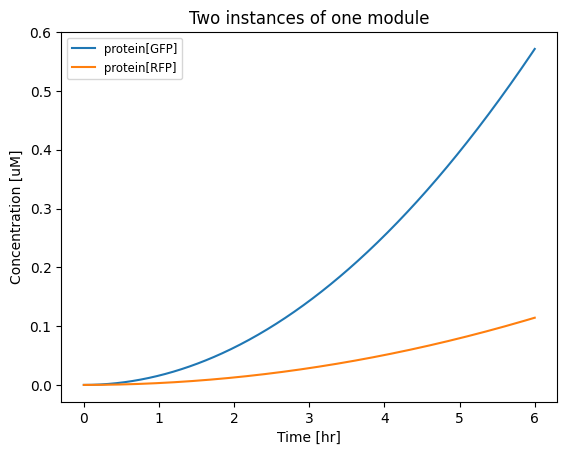

In [11]:
try:
    import bioscrape
except ModuleNotFoundError:
    print('please install the simulation libraries: pip install biocrnpyler[all]')
else:
    timepoints = np.linspace(0, 6 * hrs, 500)
    results = crn.simulate_with_bioscrape_via_sbml(
        timepoints,
        initial_condition_dict={'dna_GFP': 1 * nM, 'dna_RFP': 1 * nM},
    )

    # plot_all_species_containing collects every species containing the one
    # given, including complexes, so it follows a module's output wherever
    # it ends up.  Naming the protein Species keeps this to the proteins;
    # passing the string 'GFP' would pick up dna_GFP and rna_GFP as well.
    bcp.plot_all_species_containing(
        results,
        crn,
        [bcp.Species('GFP', material_type='protein'),
         bcp.Species('RFP', material_type='protein')],
        time_units=hrs,
        time_label='hr',
    )
    plt.title('Two instances of one module');


In [12]:
# End of example